# Random Forest - Stellar Classification (CS171)

## 1. Load, clean, split, balance

In [2]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

from imblearn.under_sampling import RandomUnderSampler

pd.set_option("display.max_columns", None)

df = pd.read_csv("./star_classification.csv")

drop_cols = [
    "obj_ID", "alpha", "delta", "run_ID", "rerun_ID",
    "cam_col", "field_ID", "spec_obj_ID", "plate",
    "MJD", "fiber_ID",
]

df.drop(columns=drop_cols, inplace=True)

cols = ["u", "g", "r", "i", "z"]
rows_to_drop = df[(df[cols] == -9999).any(axis=1)]
df = df.drop(index=rows_to_drop.index)

features = ["u", "g", "r", "i", "z", "redshift"]

X = df[features]
y = df["class"]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)


undersampler = RandomUnderSampler(random_state=42)

X_train_balanced, y_train_balanced = undersampler.fit_resample(X_train, y_train)

print("Class encoding:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print("Train / validation / test rows:", len(X_train), len(X_validation), len(X_test))
print("\nBalanced training counts:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

Class encoding: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}
Train / validation / test rows: 69999 15000 15000

Balanced training counts:
0    13273
1    13273
2    13273
Name: count, dtype: int64


## 2. Tune on the validation set

In [3]:
results = []

for n_estimators in [100, 300]:
    for max_depth in [None, 10, 20]:
        for max_features in ["sqrt", None]:
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                max_features=max_features,
                random_state=42,
                n_jobs=-1,
            )

            model.fit(X_train_balanced, y_train_balanced)

            predictions = model.predict(X_validation)

            results.append({
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "max_features": max_features,
                "Accuracy": accuracy_score(y_validation, predictions),
                "Macro F1": f1_score(y_validation, predictions, average="macro"),
            })

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
print("\nValidation tuning results:")
print(results_df.to_string(index=False))

best = results_df.iloc[0]
print("\nBest config:", best.to_dict())


Validation tuning results:
 n_estimators  max_depth max_features  Accuracy  Macro F1
          300       20.0         None  0.973333  0.969445
          100        NaN         sqrt  0.973333  0.969438
          300        NaN         sqrt  0.973200  0.969320
          300       10.0         None  0.973200  0.969243
          300        NaN         None  0.973133  0.969212
          100       20.0         None  0.973067  0.969142
          100        NaN         None  0.973000  0.969076
          100       10.0         None  0.973000  0.969027
          100       20.0         sqrt  0.972800  0.968840
          300       20.0         sqrt  0.972467  0.968509
          300       10.0         sqrt  0.971000  0.966960
          100       10.0         sqrt  0.970667  0.966580

Best config: {'n_estimators': 300, 'max_depth': 20.0, 'max_features': None, 'Accuracy': 0.9733333333333334, 'Macro F1': 0.9694452039505969}


## 3. Train best model and evaluate

In [4]:
rf = RandomForestClassifier(
    n_estimators=int(best["n_estimators"]),
    max_depth=None if pd.isna(best["max_depth"]) else int(best["max_depth"]),
    max_features=best["max_features"],
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_balanced, y_train_balanced)


def report(name, y_true, y_pred):
    print(f"\n{name} Accuracy:", accuracy_score(y_true, y_pred))
    print(f"{name} Macro Precision:", precision_score(y_true, y_pred, average="macro"))
    print(f"{name} Macro Recall:", recall_score(y_true, y_pred, average="macro"))
    print(f"{name} Macro F1:", f1_score(y_true, y_pred, average="macro"))


validation_predictions = rf.predict(X_validation)
report("Validation", y_validation, validation_predictions)

test_predictions = rf.predict(X_test)
report("Test", y_test, test_predictions)

print("\nTest classification report:")
print(classification_report(y_test, test_predictions, target_names=encoder.classes_))


Validation Accuracy: 0.9733333333333334
Validation Macro Precision: 0.9662105406915873
Validation Macro Recall: 0.972834210858792
Validation Macro F1: 0.9694452039505969

Test Accuracy: 0.9747333333333333
Test Macro Precision: 0.9667233500921908
Test Macro Recall: 0.9758543011733831
Test Macro F1: 0.9711467373120141

Test classification report:
              precision    recall  f1-score   support

      GALAXY       0.99      0.97      0.98      8917
         QSO       0.92      0.96      0.94      2844
        STAR       1.00      1.00      1.00      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.98      0.97     15000
weighted avg       0.98      0.97      0.97     15000



## 4. Charts


Feature importances:
redshift    0.882535
g           0.044444
z           0.025090
u           0.024421
i           0.013191
r           0.010319
dtype: float64


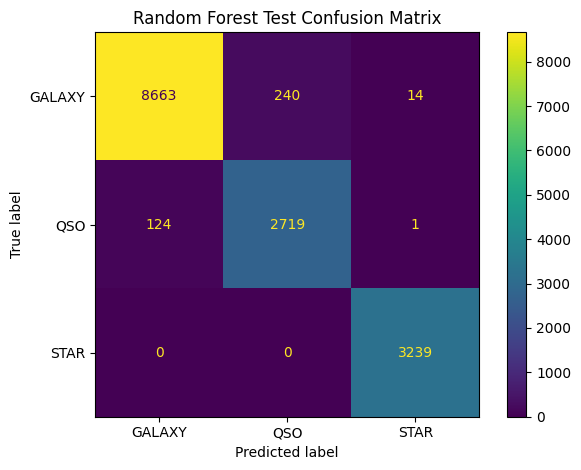

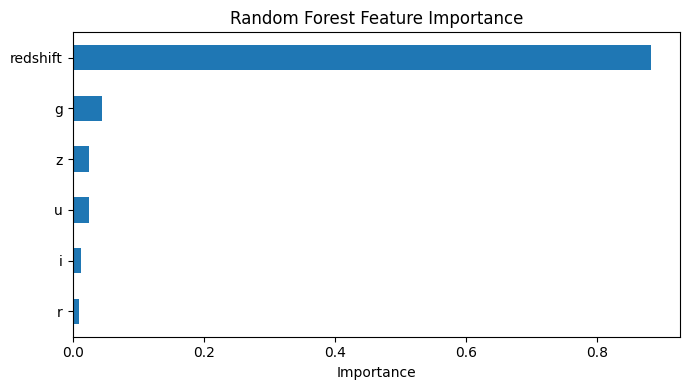

In [5]:
os.makedirs("./Model_Charts", exist_ok=True)

ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, display_labels=encoder.classes_
)
plt.title("Random Forest Test Confusion Matrix")
plt.tight_layout()
plt.savefig("./Model_Charts/rf_confusion_matrix.png", dpi=150)

importances = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(7, 4))
importances.plot.barh()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("./Model_Charts/rf_feature_importance.png", dpi=150)

print("\nFeature importances:")
print(importances.sort_values(ascending=False))

## 5. Photometry-only ablation

In [6]:
photometry = ["u", "g", "r", "i", "z"]

rf_photometry = RandomForestClassifier(
    n_estimators=int(best["n_estimators"]),
    max_depth=None if pd.isna(best["max_depth"]) else int(best["max_depth"]),
    max_features=best["max_features"],
    random_state=42,
    n_jobs=-1,
)

rf_photometry.fit(X_train_balanced[photometry], y_train_balanced)

photometry_predictions = rf_photometry.predict(X_test[photometry])
report("Test (no redshift)", y_test, photometry_predictions)

print("\nTest classification report (no redshift):")
print(classification_report(y_test, photometry_predictions, target_names=encoder.classes_))


Test (no redshift) Accuracy: 0.8566666666666667
Test (no redshift) Macro Precision: 0.8139150056329139
Test (no redshift) Macro Recall: 0.842398982452326
Test (no redshift) Macro F1: 0.8265684290599747

Test classification report (no redshift):
              precision    recall  f1-score   support

      GALAXY       0.94      0.88      0.91      8917
         QSO       0.75      0.85      0.80      2844
        STAR       0.75      0.80      0.77      3239

    accuracy                           0.86     15000
   macro avg       0.81      0.84      0.83     15000
weighted avg       0.86      0.86      0.86     15000

